In [1]:
print("Oasis Infobyte - Data Analytics")
print("Task 1: EDA on Retail Sales Data")
print("Name: Amritha H")

Oasis Infobyte - Data Analytics
Task 1: EDA on Retail Sales Data
Name: Amritha H


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("retail_sales_dataset.csv")

In [4]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
df.shape

(1000, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [7]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
df.mode(numeric_only=True).iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [11]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

monthly_sales


Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

NameError: name 'plt' is not defined

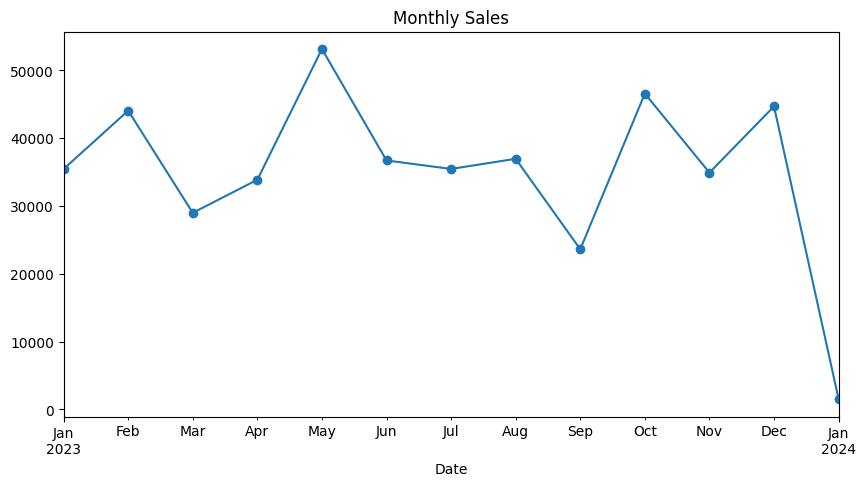

In [12]:
monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Monthly Sales"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

In [13]:
import matplotlib.pyplot as plt

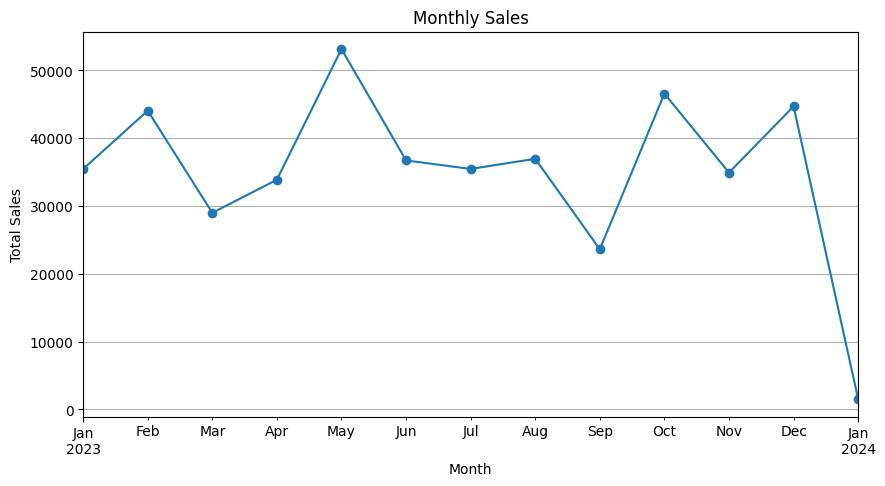

In [14]:
monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Monthly Sales"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### Observation – Monthly Sales

- Sales fluctuate considerably across the months.
- May 2023 recorded the highest monthly sales at ₹53,150.
- September 2023 recorded the lowest monthly sales among the main 2023 months at ₹23,620.
- Sales increased again in October and December 2023.
- January 2024 shows only ₹1,530 in sales because the dataset contains only a small number of transactions for that month.

In [15]:
quarterly_sales = df.groupby(
    df["Date"].dt.to_period("Q")
)["Total Amount"].sum()

quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

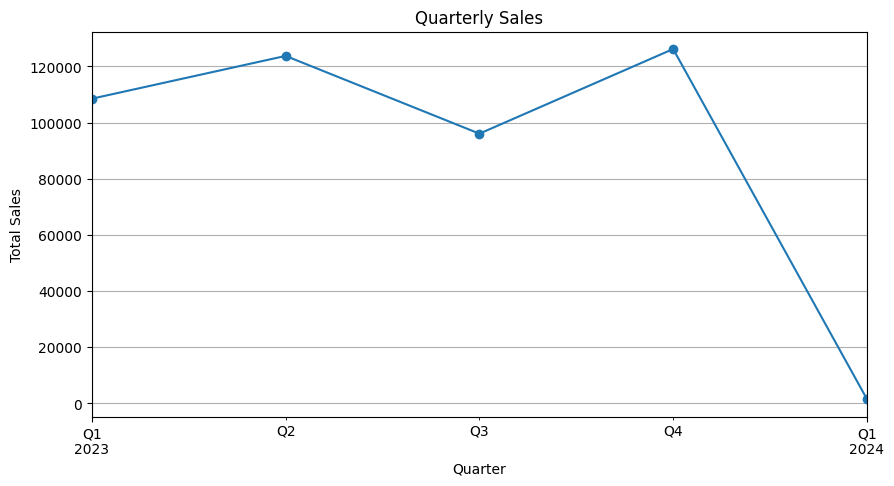

In [16]:
quarterly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Quarterly Sales"
)

plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### Observation – Quarterly Sales

- Q4 2023 recorded the highest quarterly sales at ₹126,190.
- Q2 2023 recorded the second-highest quarterly sales at ₹123,735.
- Q3 2023 had the lowest sales among the full quarters of 2023 at ₹96,045.
- Sales increased from Q3 to Q4 2023.
- Q1 2024 shows only ₹1,530 because the dataset contains only a small number of transactions in January 2024.

In [17]:
age_bins = [17, 25, 35, 45, 55, 64]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-64"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

df[["Age", "Age Group"]].head(10)

,Age,Age Group
0,34,26-35
1,26,26-35
2,50,46-55
3,37,36-45
4,30,26-35
5,45,36-45
6,46,46-55
7,30,26-35
8,63,56-64
9,52,46-55


In [18]:
age_group_counts = df["Age Group"].value_counts().sort_index()

age_group_counts

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-64    195
Name: count, dtype: int64

In [19]:
age_gender = pd.crosstab(
    df["Age Group"],
    df["Gender"]
)

age_gender

Gender,Female,Male
Age Group,,
18-25,81,88
26-35,107,98
36-45,107,95
46-55,119,110
56-64,96,99


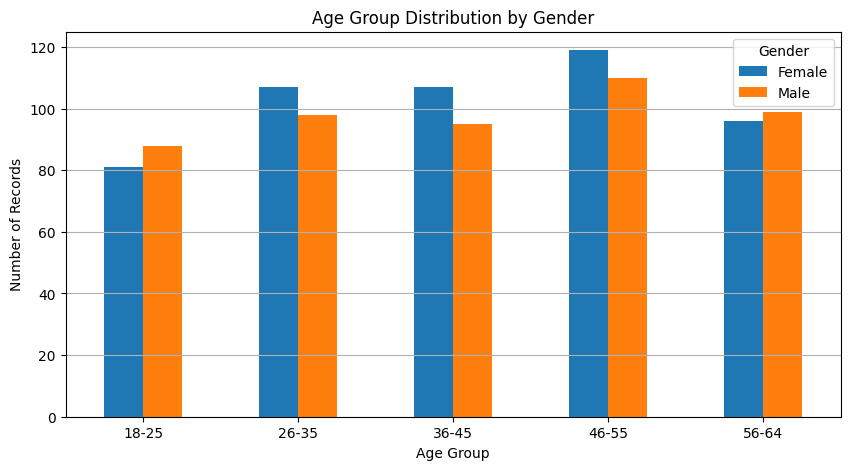

In [20]:
age_gender.plot(
    kind="bar",
    figsize=(10, 5),
    title="Age Group Distribution by Gender"
)

plt.xlabel("Age Group")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.grid(axis="y")
plt.show()

In [21]:
df["Product Category"].unique()

<StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str

In [22]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

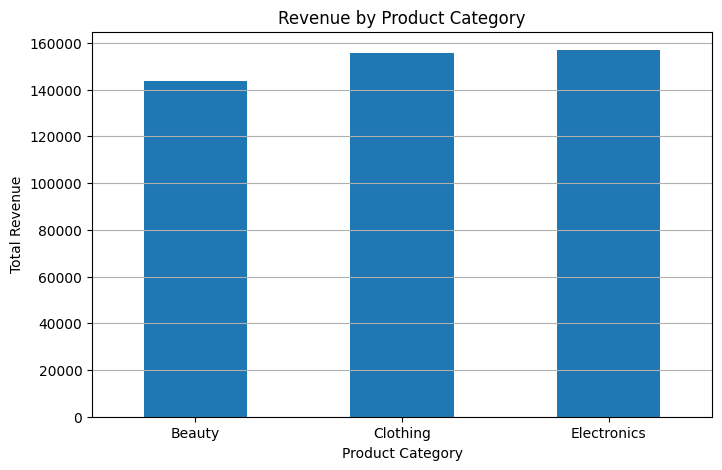

In [23]:
category_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Revenue by Product Category"
)

plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

### Observation – Revenue by Product Category

- Electronics generated the highest revenue at ₹156,905.
- Clothing generated ₹155,580 in revenue, which is very close to Electronics.
- Beauty generated the lowest revenue at ₹143,515.
- The revenue difference between the three categories is relatively small, indicating a fairly balanced contribution from each category.

In [24]:
correlation = df.select_dtypes(include="number").corr()

correlation

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

NameError: name 'sns' is not defined

<Figure size 800x600 with 0 Axes>

In [26]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

NameError: name 'sns' is not defined

<Figure size 800x600 with 0 Axes>

In [27]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

NameError: name 'sns' is not defined

<Figure size 800x600 with 0 Axes>

In [28]:
import seaborn as sns

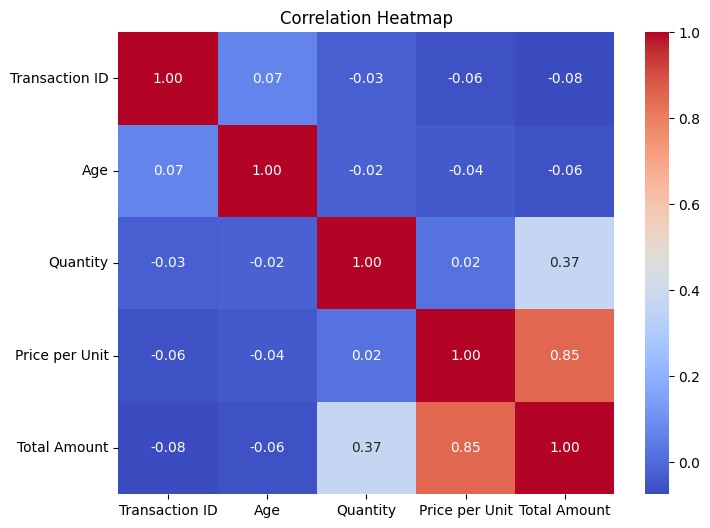

In [29]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation – Correlation Heatmap

- Price per Unit and Total Amount show a strong positive correlation of 0.85.
- Quantity and Total Amount show a moderate positive correlation of 0.37.
- Age and Total Amount show a very weak negative correlation of -0.06.
- Age and Quantity also show almost no correlation, with a value of -0.02.
- Transaction ID does not have meaningful business significance because it is an identifier.

In [30]:
product_counts = df["Product Category"].value_counts()

product_counts

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

### Note – Top 10 Products

The dataset does not contain individual product names. It only provides three product categories: Beauty, Clothing, and Electronics. Therefore, a Top 10 Products analysis cannot be performed without inventing or assuming product-level data. The available Product Category information is used for the category-level revenue analysis instead.

In [31]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

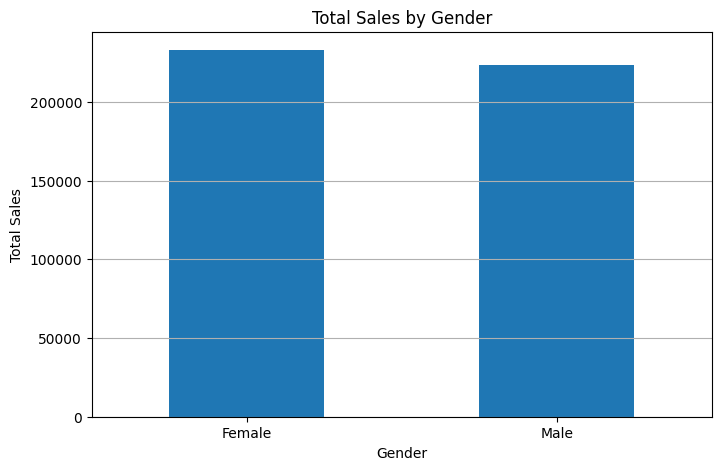

In [32]:
gender_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Sales by Gender"
)

plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

### Observation – Total Sales by Gender

- Female customers generated the highest total sales at ₹232,840.
- Male customers generated ₹223,160 in total sales.
- Female sales were slightly higher than male sales.
- The difference between the two groups is relatively small, suggesting that both genders contributed substantially to the overall sales.

In [33]:
duplicate_count = df.duplicated().sum()

duplicate_count

0

### Observation – Duplicate Check

- The dataset contains 0 duplicate records.
- Therefore, no duplicate rows were removed during the data analysis.
- This indicates that each row represents a unique transaction record in the dataset.

## Conclusion and Business Recommendations

### Conclusion

The exploratory analysis of the retail sales dataset provided useful insights into sales trends, customer demographics, and product categories.

- Sales fluctuated throughout the year, with Q4 2023 recording the highest quarterly sales of ₹126,190.
- Electronics generated the highest category revenue at ₹156,905.
- Customers aged 46–55 represented the largest age group by transaction records.
- Female customers generated slightly higher total sales than male customers.
- Price per Unit had a strong positive correlation with Total Amount (0.85).
- The dataset contains no missing values or duplicate records.
- The dataset does not contain individual product names, so a Top 10 Products analysis could not be performed.

### Actionable Business Recommendations

1. **Focus on high-performing periods:**  
   The business can plan promotions and inventory around periods with historically higher sales, particularly Q4.

2. **Strengthen the Electronics category:**  
   Since Electronics generated the highest revenue, the business can consider increasing inventory, promotions, and product variety in this category.

3. **Target different customer groups:**  
   Marketing campaigns can be tailored to different age groups and genders based on their purchasing patterns.

4. **Use pricing and quantity strategically:**  
   Since Price per Unit has a strong relationship with Total Amount, pricing and product mix should be monitored when planning sales strategies.